# DBSCAN (Density-Based Clustering)

- Groups points based on density rather than distance-to-centroid or merge order
- Automatically detects outliers/noise — points in sparse regions aren't forced into any cluster
- Dataset: creditcard.csv (transactions — using noise points as potential anomaly indicators)[https://www.kaggle.com/datasets/jacklizhi/creditcard](https://)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

In [2]:
df = pd.read_csv('/content/creditcard[1].csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61486,49862,-0.987401,1.056011,1.184880,-0.738908,-0.080874,-0.167563,0.224570,0.650254,-0.454139,-0.763572,1.077311,1.138422,-0.016053,0.399825,-0.804184,0.009106,-0.104248,-0.521008,-0.296621,-0.105403,-0.069511,-0.149341,-0.022932,0.040407,-0.291335,0.307241,0.190307,0.104660,1.00,0.0
61487,49862,0.910338,-0.976578,1.308543,0.352233,-1.228617,1.053119,-1.189630,0.422435,-0.756288,0.746956,1.587650,1.210098,1.269231,-0.205454,1.155036,-1.161051,-0.242839,1.453752,-2.030087,-0.263896,0.081774,0.571815,-0.057231,-0.292605,0.065126,-0.226463,0.114948,0.054243,129.50,0.0
61488,49863,1.033813,-0.261495,1.329732,1.820041,-0.974670,0.384867,-0.580740,0.317767,1.384514,-0.391966,-0.990866,0.541118,-1.357085,-0.514214,-1.613491,-1.192407,0.953125,-1.331861,0.054452,-0.263225,-0.398950,-0.748977,0.126709,0.367238,0.342699,-0.527094,0.082915,0.031702,22.02,0.0
61489,49863,1.446884,-0.263871,-0.192448,-0.660946,-0.598712,-1.387964,-0.001654,-0.430535,-1.207218,0.675218,-0.171897,-0.426318,0.481758,0.042767,0.383974,0.711576,0.385059,-1.643393,0.634492,0.091248,0.194922,0.511846,-0.170092,0.445334,0.805625,-0.086404,-0.026795,0.002982,15.00,0.0


In [3]:
# Dataset is large (~284k rows) and heavily imbalanced — take a manageable sample for clustering
df_sample = df.sample(n=2000, random_state=42)

# Using two PCA-derived features for visualization
X = df_sample[["V1", "V2"]]

print(df_sample["Class"].value_counts())  # 0 = normal, 1 = actual fraud (for reference only, not used by DBSCAN)

Class
0.0    1990
1.0      10
Name: count, dtype: int64


In [4]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

model = DBSCAN(eps=0.5, min_samples=5)
clusters = model.fit_predict(X_scaled)

df_sample["Cluster"] = clusters

print("Number of clusters found:", len(set(clusters)) - (1 if -1 in clusters else 0))
print("Number of noise points :", list(clusters).count(-1))

Number of clusters found: 1
Number of noise points : 32


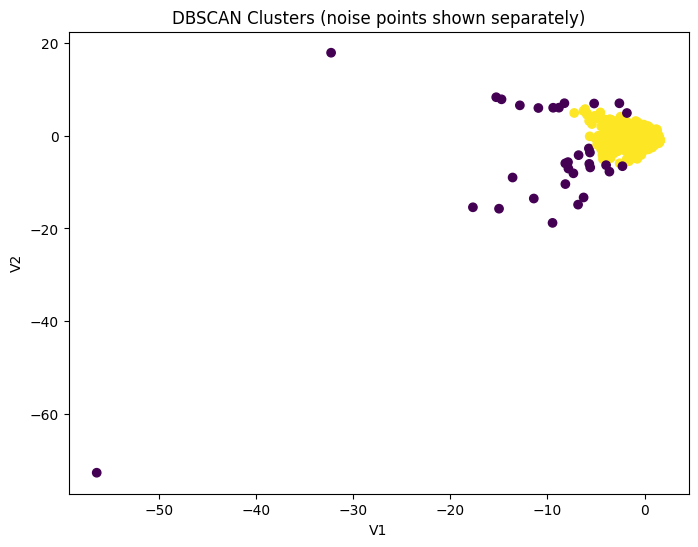

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(X["V1"], X["V2"], c=clusters, cmap="viridis")
plt.xlabel("V1")
plt.ylabel("V2")
plt.title("DBSCAN Clusters (noise points shown separately)")
plt.show()

In [6]:
noise_mask = df_sample["Cluster"] == -1

print("Total noise points flagged   :", noise_mask.sum())
print("Actual fraud among noise pts :", df_sample.loc[noise_mask, "Class"].sum())
print("Actual fraud in full sample  :", df_sample["Class"].sum())

Total noise points flagged   : 32
Actual fraud among noise pts : 6.0
Actual fraud in full sample  : 10.0


## Conclusion
- DBSCAN grouped dense regions of transactions into clusters, without needing to specify K upfront
- Points that didn't belong to any dense region were automatically labeled as noise (-1)
- Comparing noise points to the actual fraud label shows DBSCAN's "noise" overlaps meaningfully with real anomalies — even though it was never told which transactions were fraud
- This is the key advantage over K-Means/Hierarchical: instead of forcing every point into a cluster, DBSCAN naturally separates out unusual points

Save as DBSCAN.ipynb
Upload to 03_Machine_Learning/06_Unsupervised_Learning/